In [1]:
import pandas as pd
import networkx as nx

df = pd.read_csv("../data/delivery_data.csv")

In [2]:
df["delay_ratio"] = (
    df["actual_time"] /
    df["osrm_time"]
)

In [3]:
corridor_df = (
    df.groupby(
        ["source_center", "destination_center"]
    )["delay_ratio"]
    .median()
    .reset_index()
)

In [4]:
corridor_df.head()

,source_center,destination_center,delay_ratio
0,IND000000AAL,IND411033AAA,2.416667
1,IND000000AAQ,IND700028AAB,6.071429
2,IND000000AAS,IND783370AAC,1.711279
3,IND000000AAZ,IND444203AAA,4.365854
4,IND000000AAZ,IND444303AAA,4.000000


In [5]:
G = nx.from_pandas_edgelist(
    corridor_df,
    source="source_center",
    target="destination_center",
    edge_attr="delay_ratio",
    create_using=nx.DiGraph()
)

In [6]:
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 1657
Number of edges: 2783


In [7]:
list(G.edges(data=True))[:10]

[('IND000000AAL', 'IND411033AAA', {'delay_ratio': 2.4166666666666665}),
 ('IND411033AAA', 'IND000000AAL', {'delay_ratio': 2.7037037037037037}),
 ('IND411033AAA', 'IND000000ACB', {'delay_ratio': 1.6259825254974918}),
 ('IND411033AAA', 'IND400072AAB', {'delay_ratio': 1.8991307292842627}),
 ('IND411033AAA', 'IND403726AAA', {'delay_ratio': 2.2467532467532467}),
 ('IND411033AAA', 'IND410503AAA', {'delay_ratio': 2.2857142857142856}),
 ('IND411033AAA', 'IND410505AAB', {'delay_ratio': 1.5258620689655173}),
 ('IND411033AAA', 'IND411014AAA', {'delay_ratio': 2.3524844720496896}),
 ('IND411033AAA', 'IND411021AAA', {'delay_ratio': 1.9230769230769231}),
 ('IND411033AAA', 'IND411036AAA', {'delay_ratio': 1.75})]

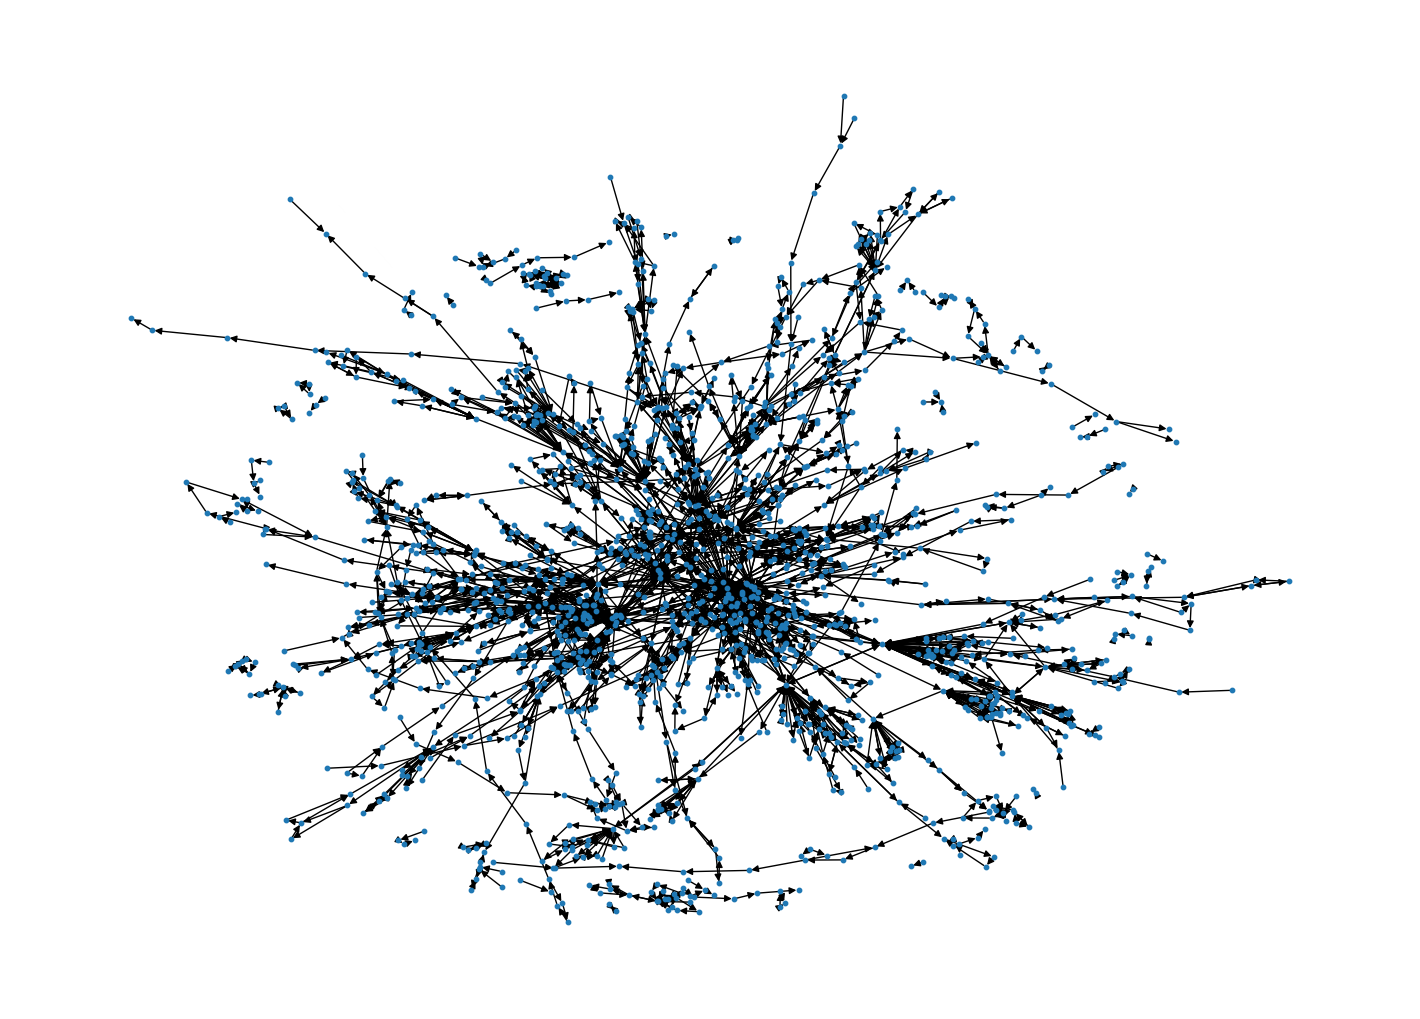

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

nx.draw(
    G,
    with_labels=False,
    node_size=10,
    arrows=True
)

plt.show()